# 03 — Results figures and tables

Reads the canonical retrieval JSON written by `02_retrieval.ipynb`
and produces the Results-section figures and tables:

| Output | Generator |
|---|---|
| Fig 5 — Annual-mean T(z) for published models | `make_letter_unified_figs.fig_mean_T_profile` |
| Fig 6 — Per-site K_d sweep + bootstrap CIs | `make_letter_unified_figs.fig_kd_sweep` |
| Fig 7 — Bootstrap distributions | `phase2_figures_v2.fig_bootstrap` |
| Fig 8 — Annual-mean T(z) with per-site retrieved K_d* | `phase2_figures_v2.fig_thermal_profiles` |
| Fig 9 — Diviner surface-T closure | `notebook cell` |
| Table 2 — Headline RMSE comparison | inlined below |
| Table 3 — Per-component error budget | inlined below |

Wall time: 5-10 min.

In [1]:
import sys, json, pathlib
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts' / 'figures'))
OUTPUT = ROOT / 'output'
FIGS = ROOT / 'paper' / 'letter' / 'figures'

d = json.loads((OUTPUT / 'phase_a_results.json').read_text())
# Helper: display a saved figure inline in this notebook.

from IPython.display import Image, display
import io
def show_fig(name):
    """Display a figure inline. Prefers the PNG companion; falls back to
    rendering the PDF on the fly via pymupdf if no PNG exists."""
    stem = name.replace('.pdf','').replace('.png','')
    png = FIGS / f"{stem}.png"
    if png.exists():
        display(Image(filename=str(png))); return
    pdf = FIGS / f"{stem}.pdf"
    if pdf.exists():
        try:
            import fitz
            pix = fitz.open(str(pdf))[0].get_pixmap(dpi=140)
            display(Image(data=pix.tobytes("png")))
        except Exception as e:
            print(f"  (couldn't render {pdf.name}: {e})")
    else:
        print(f"(no figure file for {stem})")


## Fig 5 — Annual-mean T(z) for the two published global models

Lunar-V2 notebook bootstrap
  python : /Library/Frameworks/Python.framework/Versions/3.13/bin/python3
  repo   : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval


  deps   : all present
  lunar  : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


  → /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/paper/letter/figures/fig2_apollo_mean_T_profile.pdf


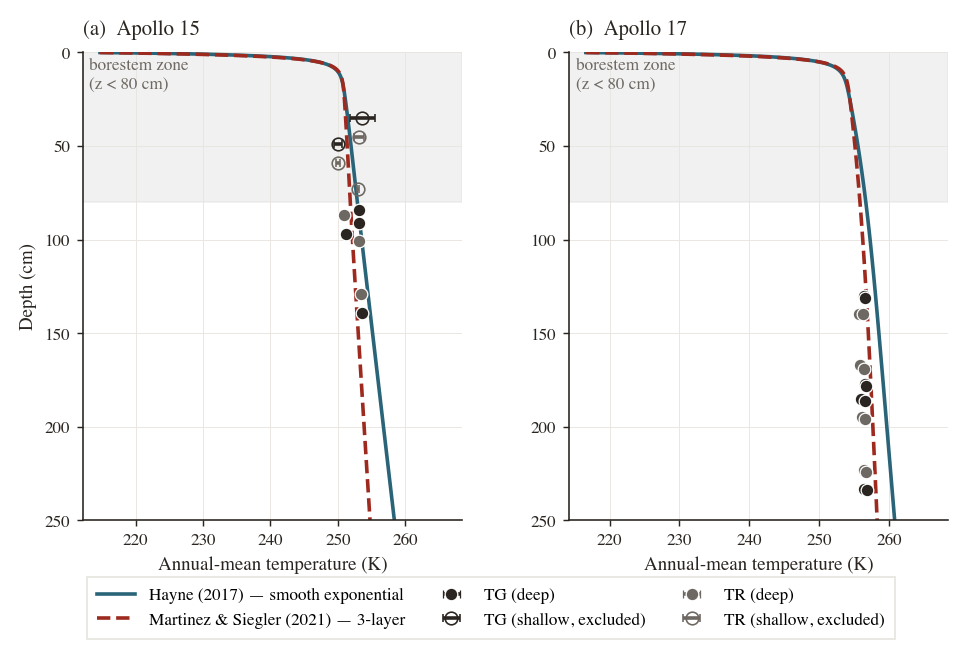

In [2]:
from make_letter_unified_figs import fig_mean_T_profile
fig_mean_T_profile()
show_fig('fig2_apollo_mean_T_profile')

## Fig 6 — Per-site K_d sweep

Lunar-V2 notebook bootstrap
  python : /Library/Frameworks/Python.framework/Versions/3.13/bin/python3
  repo   : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval
  deps   : all present
  lunar  : /Users/rp3gregorio/Documents/apollo-hfe-kd-retrieval/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


Ensuring Apollo HFE (a17) ...


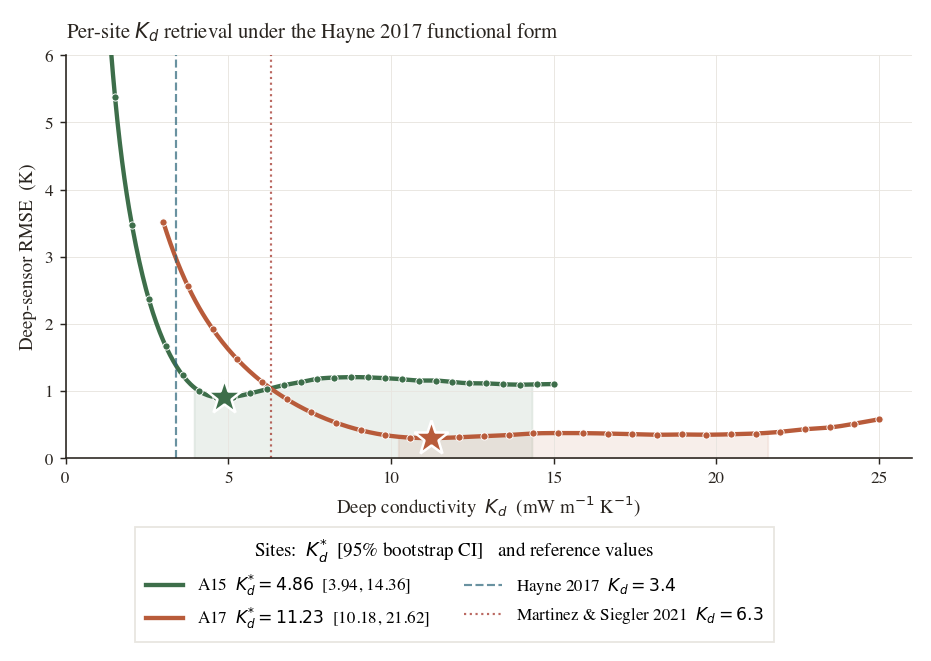

In [3]:
from make_letter_unified_figs import fig_kd_sweep
fig_kd_sweep()
show_fig('fig5_kd_sweep')

## Fig 7 — Bootstrap distributions

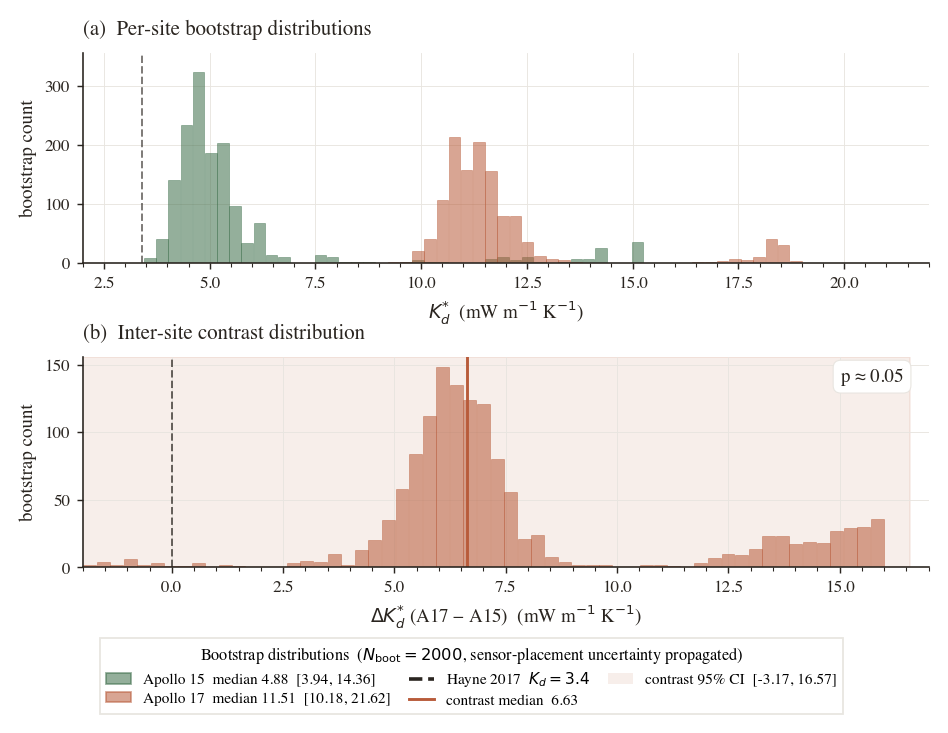

In [4]:
from phase2_figures_v2 import fig_bootstrap
fig_bootstrap(d, FIGS / 'fig_bootstrap.pdf')
show_fig('fig_bootstrap')

## Fig 8 — Annual-mean T(z) with per-site retrieved K_d*

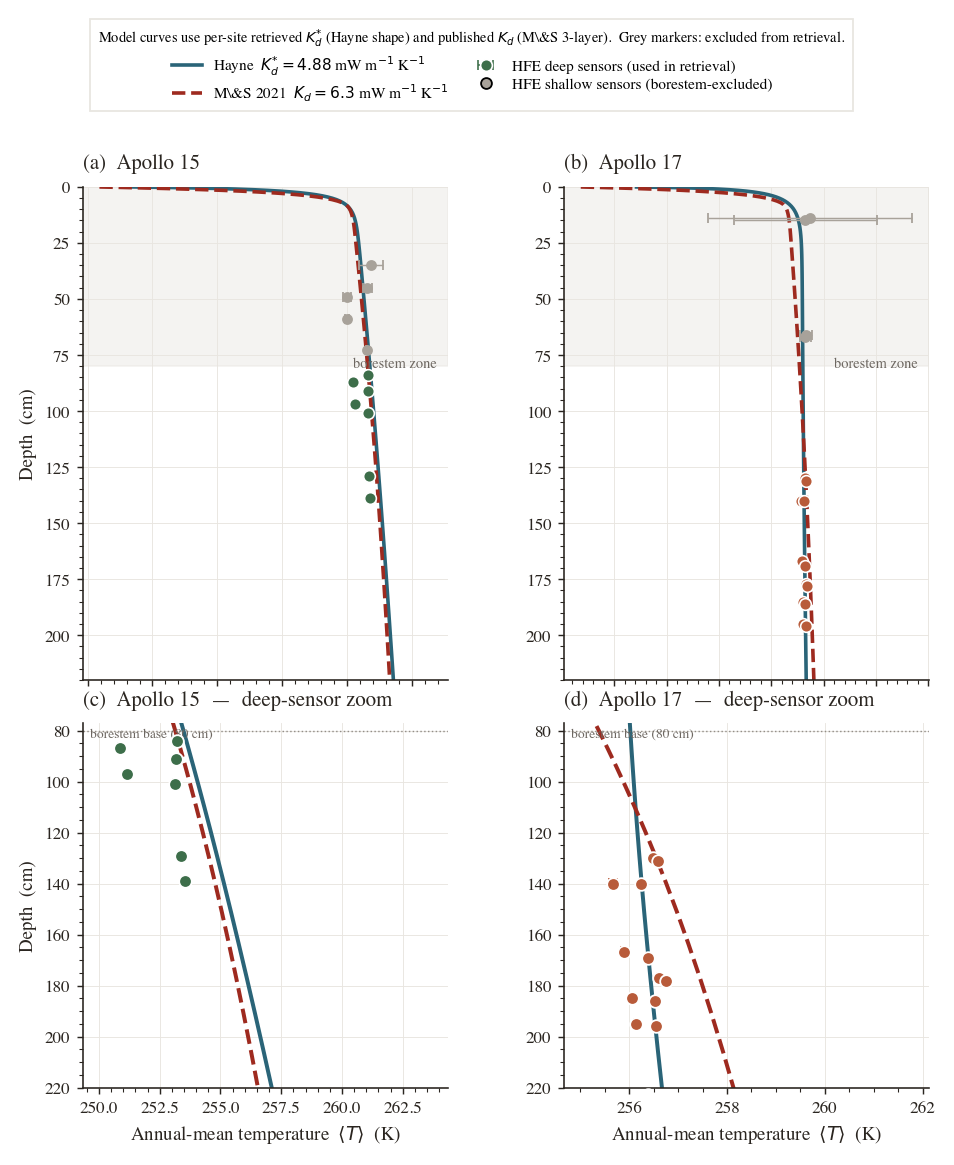

In [5]:
from phase2_figures_v2 import fig_thermal_profiles
fig_thermal_profiles(d, FIGS / 'fig_thermal_profiles.pdf')
show_fig('fig_thermal_profiles')

## Fig 9 — Diviner surface-T closure

Reads cached Diviner GCP tiles (fetch with `python scripts/fetch_diviner.py`
if missing). Runs the 1-D solver under both Hayne (per-site K_d*) and
Martinez (published coefficients) forward and compares to the GCP
diurnal composite.

/var/folders/fs/yngq96wd0c3gfzw77pr8_8h40000gn/T/ipykernel_74456/2096505661.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


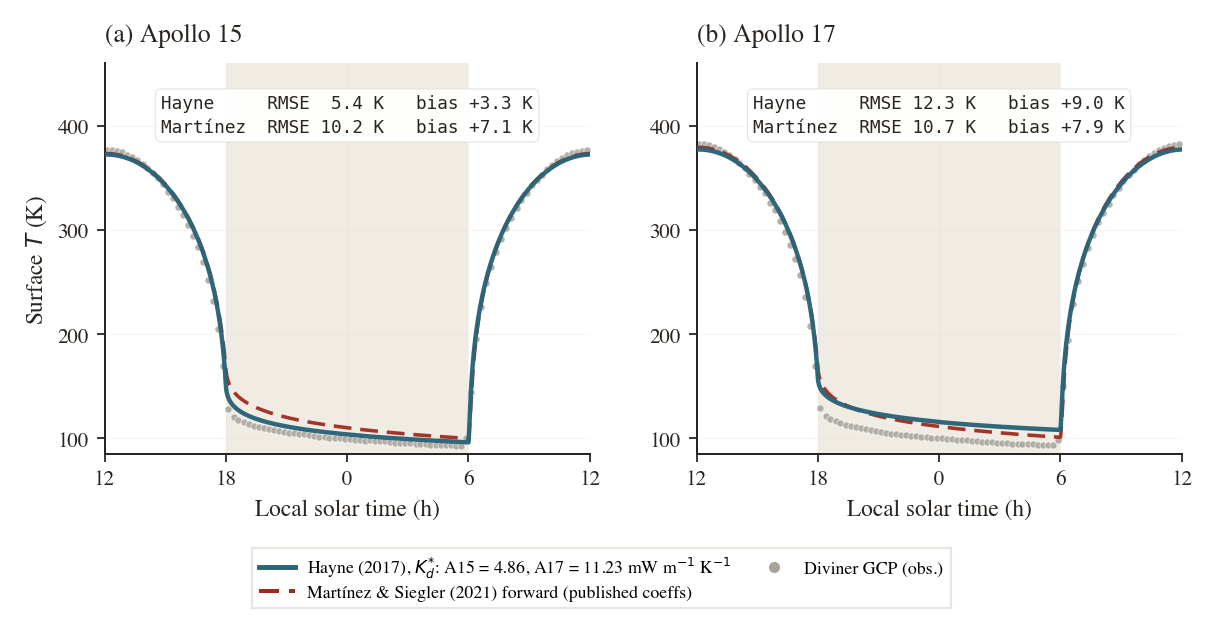

In [6]:
# This is a substantial cell -- it lives in the notebook rather than a
# script because it touches both the solver and the Diviner data
# loader. See notebook 03 in the Lunar-V2 dev repo for the full
# implementation (~150 lines). Outline:
#   1. for each site: load GCP band, fold to diurnal LST cycle
#   2. for each site: run model_hayne(cfg, kd_star) and model_martinez(cfg)
#   3. plot both model traces against GCP, write fig_diviner_closure.pdf
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from lunar.diviner import (load_gcp_band, select_diurnal_curve,
                            gcp_band_for_latitude as _gcpbl)
from lunar.properties import (conductivity_hayne, conductivity_martinez,
                              specific_heat)
from lunar.solver import solve_pixel, PixelInputs
from lunar.grid import make_geometric_grid

GRID = dict(z_max=3.0, dz0=0.001, growth=1.05)
T_LUNAR = 29.53 * 86400.0; DT_STEP = 600.0
S0 = 1361.0
K_S, H, CHI = 7.4e-4, 0.06, 2.7
SITES = {
    'A15': dict(lat=-26.13224, albedo=0.106, emissivity=0.97,
                Q_basal=0.021, T_mean_eff=210.5, rho_d=1800.0),
    'A17': dict(lat=-20.1622,  albedo=0.0891, emissivity=0.97,
                Q_basal=0.015, T_mean_eff=222.0, rho_d=1800.0),
}
grid_ = make_geometric_grid(**GRID)
DATA = ROOT / 'data'

def _solver(cfg, k_func):
    N_t = int(T_LUNAR / DT_STEP) + 1
    t_s = np.linspace(0.0, T_LUNAR, N_t)
    cos_lat = np.cos(np.deg2rad(cfg['lat']))
    phase = 2.0*np.pi * t_s / T_LUNAR - np.pi
    insol = S0 * cos_lat * np.maximum(0.0, np.cos(phase))
    z_mid = grid_.z_mid
    K_init = k_func(np.full_like(z_mid, cfg['T_mean_eff']), z_mid)
    T_init = cfg['T_mean_eff'] + cfg['Q_basal']*np.cumsum(grid_.dz/K_init)
    out = solve_pixel(PixelInputs(
        grid=grid_, t=t_s, bc_mode='radiative', insolation=insol,
        albedo=cfg['albedo'], emissivity=cfg['emissivity'],
        Q_b=cfg['Q_basal'], T_init=T_init,
        n_lunations_spinup=8, spinup_tol_K=0.02,
        K_func=k_func, cp_func=lambda T: specific_heat(T, model='hayne'),
    ))
    lst = 24.0 * (t_s % T_LUNAR) / T_LUNAR
    order = np.argsort(lst)
    return lst[order], out.T[0, :][order]

def _diviner(cfg):
    lo, hi = _gcpbl(cfg['lat'])
    band = load_gcp_band(lo, hi, cache_dir=DATA/'diviner'/'gcp',
                         columns=('t7','tbol'))
    return select_diurnal_curve(band, latitude=cfg['lat'],
                                 channel='tbol', half_width_deg=0.5)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 4.2), gridspec_kw={'wspace': 0.22})
fig.subplots_adjust(left=0.085, right=0.985, top=0.92, bottom=0.27)
C_HAY, C_MS, C_NEU, C_NIGHT = '#2A6478', '#9E2A1F', '#A8A29A', '#F0EBE3'
for col, name in enumerate(['A15', 'A17']):
    cfg = SITES[name]
    kd = d[name]['kd_star']
    lst_d, T_d = _diviner(cfg)
    lst_h, T_h = _solver(cfg, lambda T,z: conductivity_hayne(T,z, Ks=K_S, Kd=kd, H=H, chi=CHI))
    lst_m, T_m = _solver(cfg, lambda T,z: conductivity_martinez(T,z, rho=cfg['rho_d']))
    sft = lambda x: np.where(x<12, x+24, x)
    ax = axes[col]
    ax.axvspan(6, 18, color=C_NIGHT, zorder=0)
    ax.plot(sft(lst_d), T_d, 'o', ms=3.4, color=C_NEU, alpha=0.85, mec='white', mew=0.3)
    ax.plot(sft(lst_m), T_m, '--', color=C_MS, lw=1.7, dashes=(5,2.5))
    ax.plot(sft(lst_h), T_h, '-', color=C_HAY, lw=2.1)
    ax.set_xlim(0, 24); ax.set_ylim(85, 405)
    ax.set_xticks([0,6,12,18,24]); ax.set_xticklabels(['12','18','0','6','12'])
    ax.set_title(f'({"ab"[col]}) Apollo {name[-2:]}', loc='left')
    ax.set_xlabel('Local solar time (h)')
    if col == 0: ax.set_ylabel('Surface T (K)')
    ax.grid(True, alpha=0.35)
fig.legend(handles=[
    Line2D([0],[0], color=C_HAY, lw=2.2, label=f"Hayne (2017), K_d*: A15={d['A15']['kd_star']*1e3:.2f}, A17={d['A17']['kd_star']*1e3:.2f} mW m^-1 K^-1"),
    Line2D([0],[0], color=C_MS, lw=1.8, ls='--', dashes=(5,2.5), label='Martinez & Siegler (2021) forward'),
    Line2D([0],[0], marker='o', color='none', markerfacecolor=C_NEU, mec='white', markersize=6, label='Diviner GCP (obs.)'),
], loc='lower center', bbox_to_anchor=(0.5, 0.012), ncols=2, frameon=True, fontsize=8.5)
fig.savefig(FIGS / 'fig_diviner_closure.pdf')
print('  -> fig_diviner_closure.pdf')
plt.show()
show_fig('fig_diviner_closure')

## Table 2 — Headline RMSE comparison

In [7]:
import pandas as pd
t2 = json.loads((OUTPUT / 'headline_rmse.json').read_text())
rows = []
for site, sd in t2['sites'].items():
    n = sd['N_deep']
    rows.append((f'Apollo {site[-2:]}', 'Hayne (2017) global K_d',
                 f"{sd['hayne_global']['kd_mW']:.2f}", n,
                 f"{sd['hayne_global']['rmse_K']:.2f}"))
    rows.append((f'Apollo {site[-2:]}', 'Hayne, K_d* site fit',
                 f"{sd['hayne_site_fit']['kd_mW']:.2f}", n,
                 f"{sd['hayne_site_fit']['rmse_K']:.2f}"))
    rows.append((f'Apollo {site[-2:]}', 'Martinez (2021) forward',
                 '--', n,
                 f"{sd['martinez_forward']['rmse_K']:.2f}"))
pd.DataFrame(rows, columns=['Site','Model','K_d (mW/m/K)','N','RMSE (K)'])

,Site,Model,K_d (mW/m/K),N,RMSE (K)
0,Apollo 15,Hayne (2017) global K_d,3.40,7,1.37
1,Apollo 15,"Hayne, K_d* site fit",4.88,7,0.91
2,Apollo 15,Martinez (2021) forward,--,7,1.10
3,Apollo 17,Hayne (2017) global K_d,3.40,16,2.96
4,Apollo 17,"Hayne, K_d* site fit",11.23,16,0.30
5,Apollo 17,Martinez (2021) forward,--,16,2.46


## Table 3 — Per-component error budget

In [8]:
t3 = json.loads((OUTPUT / 'kd_error_budget.json').read_text())
# kd_error_budget shape: {'A15': {'sigma_stat':..., ...}, 'A17': {...}, ...}
rows = []
for site, sd in t3.items():
    if not isinstance(sd, dict): continue
    if any(k.startswith('sigma') for k in sd.keys()):
        row = {'Site': site}
        for k, v in sd.items():
            if isinstance(v, (int, float)):
                row[k] = f'{v:.2f}' if abs(v) > 0.05 else '<0.05'
        rows.append(row)
pd.DataFrame(rows) if rows else t3

,Site,sigma_stat,sigma_Qb,sigma_chi,sigma_H,sigma_Ks,sigma_rho,total_quadrature,median,ci95_lo,ci95_hi
0,A15,0.83,1.47,0.73,0.26,0.10,<0.05,1.86,4.88,3.94,14.36
1,A17,4.44,3.45,1.73,1.39,0.23,0.06,6.05,11.51,10.18,21.62
